# V-JEPA - Visual Experiments

> **Goal:** Explore why video feature prediction needs spatiotemporal tube masks and what V-JEPA does, and does not, learn from its masked-completion objective.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Temporal leakage** | Why must a spatial mask persist across time? |
| 2 | **Short- and long-range masks** | How do the two mask families change task difficulty? |
| 3 | **Feature targets vs texture** | Why can latent prediction ignore unpredictable video detail? |
| 4 | **Completion vs forecasting** | Why is masked video completion not automatically a causal future model? |

---
**Linked theory:** [research/08-v-jepa.md](../research/08-v-jepa.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
})

def rectangle_mask(height, width, row, col, block_height, block_width):
    mask = np.zeros((height, width), dtype=bool)
    mask[row:row + block_height, col:col + block_width] = True
    return mask

def temporal_copy_leakage(target_mask):
    visible = ~target_mask
    leaked = np.zeros_like(target_mask)
    leaked[1:] |= target_mask[1:] & visible[:-1]
    leaked[:-1] |= target_mask[:-1] & visible[1:]
    return leaked.sum() / max(target_mask.sum(), 1)

---
## Experiment 1: Temporal leakage from frame-local masks

**Question:** Why does V-JEPA repeat a spatial block across the temporal dimension?

Adjacent video frames are highly redundant. If a target location is masked in only one frame, the same location is often visible immediately before or after it. A tube mask removes that shortcut.

In [2]:
time_exp1, height_exp1, width_exp1 = 8, 12, 12
yy_exp1, xx_exp1 = np.mgrid[:height_exp1, :width_exp1]
video_exp1 = np.zeros((time_exp1, height_exp1, width_exp1))

for time_index in range(time_exp1):
    center_x = 2.0 + 0.9 * time_index
    center_y = 5.5 + 0.8 * np.sin(time_index / 2)
    video_exp1[time_index] = np.exp(
        -((xx_exp1 - center_x) ** 2 + (yy_exp1 - center_y) ** 2) / 3.0
    )

tube_spatial_exp1 = rectangle_mask(height_exp1, width_exp1, 3, 4, 6, 5)
tube_mask_exp1 = np.broadcast_to(tube_spatial_exp1, video_exp1.shape).copy()

rng_exp1 = np.random.default_rng(7)
frame_local_mask_exp1 = np.zeros_like(tube_mask_exp1)
for time_index in range(time_exp1):
    row = rng_exp1.integers(0, height_exp1 - 5)
    col = rng_exp1.integers(0, width_exp1 - 4)
    frame_local_mask_exp1[time_index] = rectangle_mask(height_exp1, width_exp1, row, col, 5, 4)

tube_leakage_exp1 = temporal_copy_leakage(tube_mask_exp1)
local_leakage_exp1 = temporal_copy_leakage(frame_local_mask_exp1)

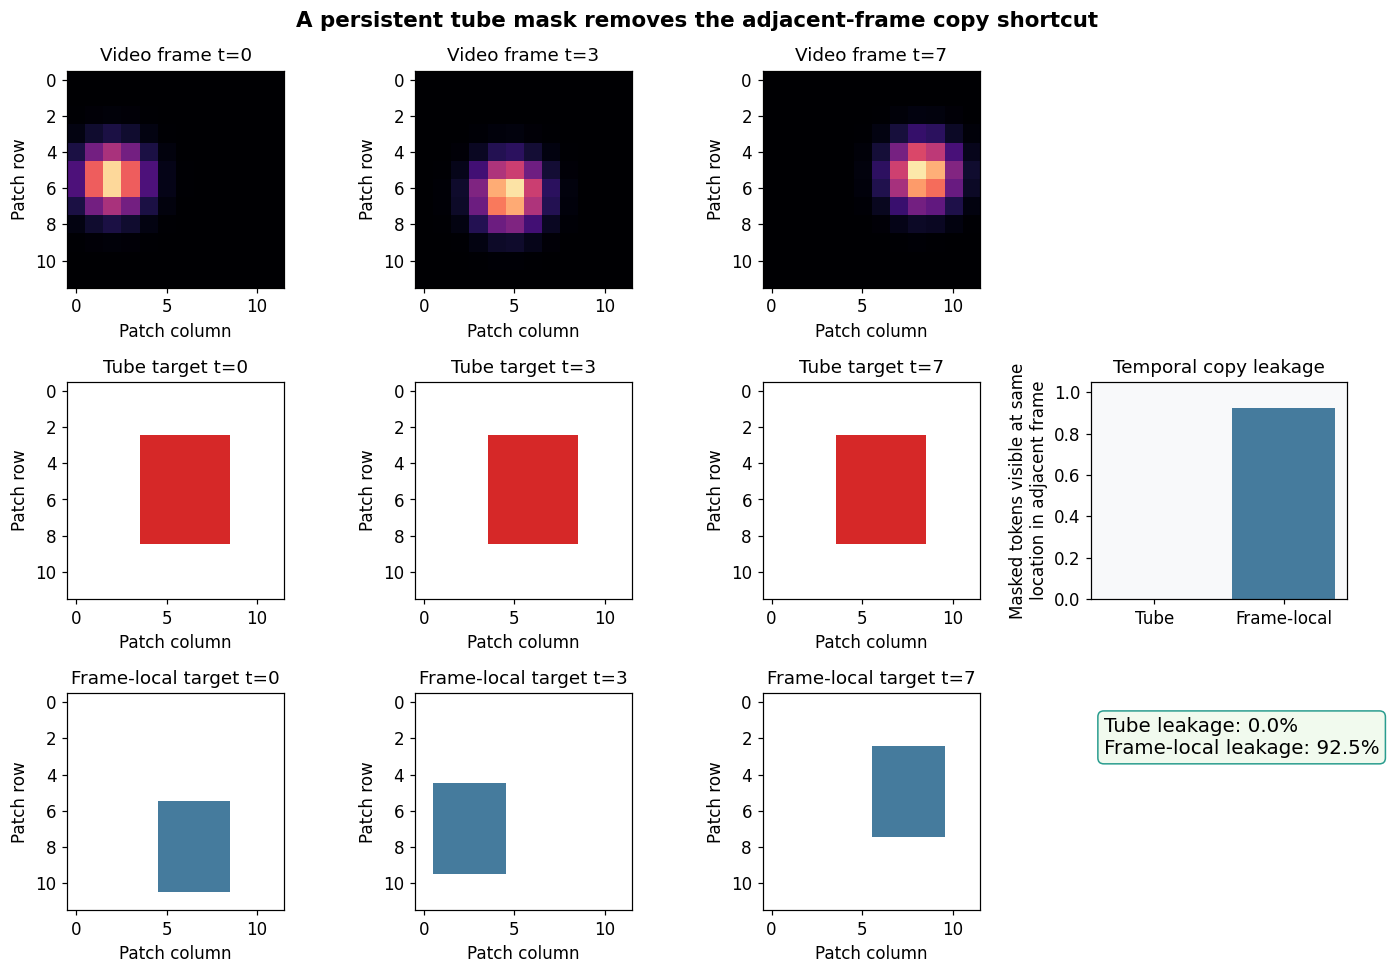

In [3]:
selected_times_exp1 = [0, 3, 7]
fig, axes = plt.subplots(3, 4, figsize=(13, 9))
fig.suptitle('A persistent tube mask removes the adjacent-frame copy shortcut', fontsize=14, fontweight='bold')

for column, time_index in enumerate(selected_times_exp1):
    axes[0, column].imshow(video_exp1[time_index], cmap='magma', vmin=0, vmax=1)
    axes[0, column].set_title(f'Video frame t={time_index}')
    axes[1, column].imshow(tube_mask_exp1[time_index], cmap=ListedColormap(['white', '#d62828']))
    axes[1, column].set_title(f'Tube target t={time_index}')
    axes[2, column].imshow(frame_local_mask_exp1[time_index], cmap=ListedColormap(['white', '#457b9d']))
    axes[2, column].set_title(f'Frame-local target t={time_index}')
    for row in range(3):
        axes[row, column].set_xlabel('Patch column')
        axes[row, column].set_ylabel('Patch row')

axes[0, 3].axis('off')
axes[1, 3].bar(['Tube', 'Frame-local'], [tube_leakage_exp1, local_leakage_exp1], color=['#d62828', '#457b9d'])
axes[1, 3].set_ylim(0, 1.05)
axes[1, 3].set_ylabel('Masked tokens visible at same\nlocation in adjacent frame')
axes[1, 3].set_title('Temporal copy leakage')
axes[2, 3].axis('off')
axes[2, 3].text(
    0.05, 0.72,
    f'Tube leakage: {tube_leakage_exp1:.1%}\nFrame-local leakage: {local_leakage_exp1:.1%}',
    fontsize=13,
    bbox=dict(boxstyle='round', facecolor='#f1faee', edgecolor='#2a9d8f'),
)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The tube removes the same spatial region in every frame, while frame-local targets move around and expose many target locations in adjacent frames.
2. **Why it looks this way:** Slowly changing videos make neighboring frames near-duplicates. A one-frame hole can often be solved by copying rather than understanding motion or object structure.
3. **Key takeaway:** Spatiotemporal tubes are an anti-shortcut mechanism.

---
## Experiment 2: Short- and long-range multi-block masks

**Question:** What changes when V-JEPA combines many small blocks with a few large blocks?

The paper uses eight roughly 15% blocks for short-range masks and two roughly 70% blocks for long-range masks. Their unions expose different context geometries even when both remove most tokens.

In [4]:
height_exp2 = width_exp2 = 24
rng_exp2 = np.random.default_rng(19)

def sample_block_union(block_count, block_height, block_width, rng):
    union = np.zeros((height_exp2, width_exp2), dtype=bool)
    blocks = []
    for _ in range(block_count):
        row = rng.integers(0, height_exp2 - block_height + 1)
        col = rng.integers(0, width_exp2 - block_width + 1)
        block = rectangle_mask(height_exp2, width_exp2, row, col, block_height, block_width)
        blocks.append(block)
        union |= block
    return union, blocks

short_union_exp2, short_blocks_exp2 = sample_block_union(8, 8, 11, rng_exp2)
long_union_exp2, long_blocks_exp2 = sample_block_union(2, 18, 22, rng_exp2)

short_labels_exp2 = np.zeros((height_exp2, width_exp2))
for index, block in enumerate(short_blocks_exp2, start=1):
    short_labels_exp2[block] = index

long_labels_exp2 = np.zeros((height_exp2, width_exp2))
for index, block in enumerate(long_blocks_exp2, start=1):
    long_labels_exp2[block] = index

short_ratio_exp2 = short_union_exp2.mean()
long_ratio_exp2 = long_union_exp2.mean()

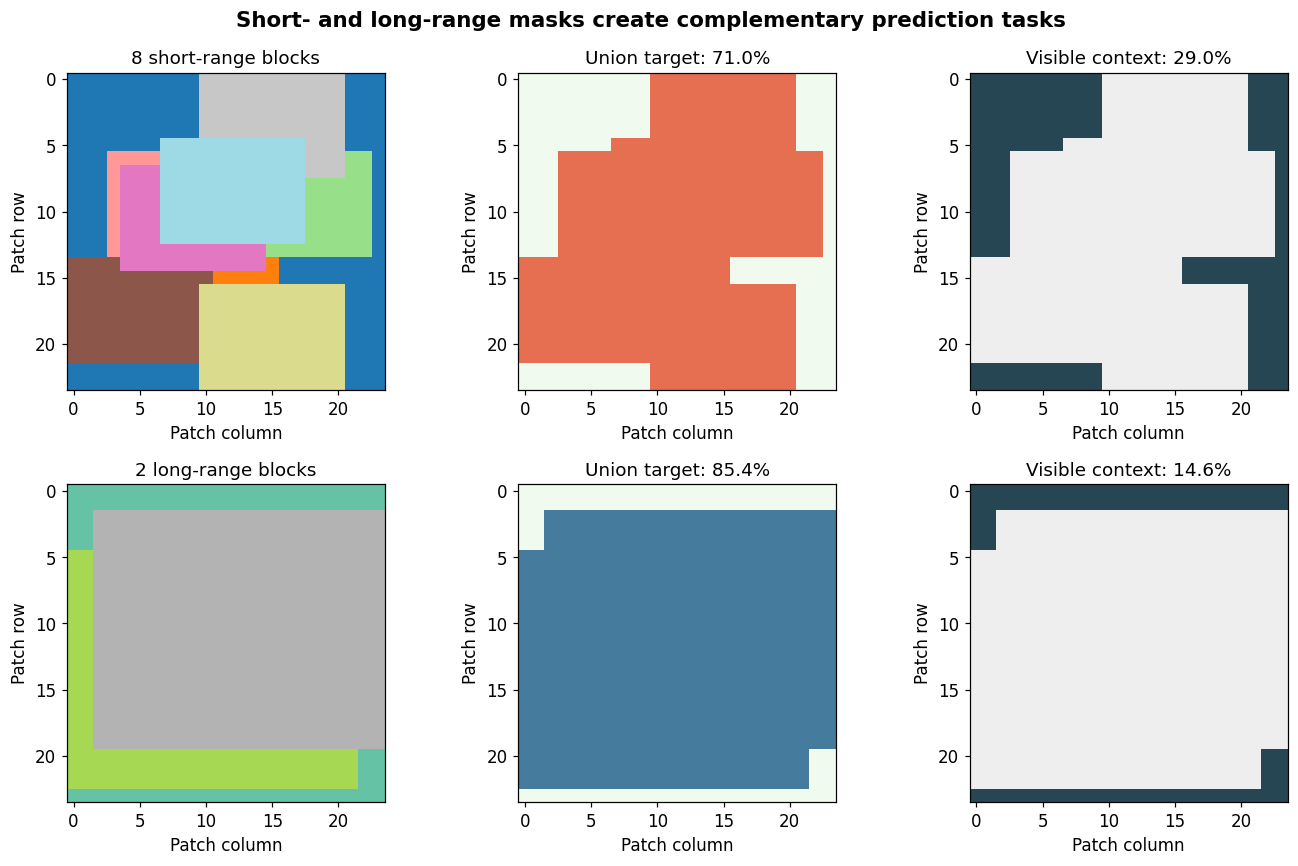

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12.5, 8))
fig.suptitle('Short- and long-range masks create complementary prediction tasks', fontsize=14, fontweight='bold')

axes[0, 0].imshow(short_labels_exp2, cmap='tab20')
axes[0, 0].set_title('8 short-range blocks')
axes[0, 1].imshow(short_union_exp2, cmap=ListedColormap(['#f1faee', '#e76f51']))
axes[0, 1].set_title(f'Union target: {short_ratio_exp2:.1%}')
axes[0, 2].imshow(~short_union_exp2, cmap=ListedColormap(['#eeeeee', '#264653']))
axes[0, 2].set_title(f'Visible context: {(~short_union_exp2).mean():.1%}')

axes[1, 0].imshow(long_labels_exp2, cmap='Set2')
axes[1, 0].set_title('2 long-range blocks')
axes[1, 1].imshow(long_union_exp2, cmap=ListedColormap(['#f1faee', '#457b9d']))
axes[1, 1].set_title(f'Union target: {long_ratio_exp2:.1%}')
axes[1, 2].imshow(~long_union_exp2, cmap=ListedColormap(['#eeeeee', '#264653']))
axes[1, 2].set_title(f'Visible context: {(~long_union_exp2).mean():.1%}')

for ax in axes.ravel():
    ax.set_xlabel('Patch column')
    ax.set_ylabel('Patch row')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Many smaller blocks leave fragmented context around several targets; two large blocks leave a small, globally distributed complement.
2. **Why it looks this way:** Block union and overlap determine the realized mask ratio. A single draw need not equal the paper's dataset average of about 90%.
3. **Key takeaway:** Mixing mask families asks the encoder to support both local completion and global scene-level inference.

---
## Experiment 3: Feature targets can ignore unpredictable texture

**Question:** Why can prediction in representation space be more efficient than pixel reconstruction?

Each synthetic clip contains the same predictable moving object plus independent high-frequency texture. A pixel target includes both components; a semantic target keeps only position and velocity.

In [6]:
rng_exp3 = np.random.default_rng(23)
time_exp3, height_exp3, width_exp3 = 10, 28, 28
yy_exp3, xx_exp3 = np.mgrid[:height_exp3, :width_exp3]
semantic_video_exp3 = np.zeros((time_exp3, height_exp3, width_exp3))
centers_exp3 = []

for time_index in range(time_exp3):
    center_x = 5.0 + 1.5 * time_index
    center_y = 10.0 + 0.6 * time_index
    centers_exp3.append((center_x, center_y))
    semantic_video_exp3[time_index] = np.exp(
        -((xx_exp3 - center_x) ** 2 + (yy_exp3 - center_y) ** 2) / 9.0
    )

texture_levels_exp3 = np.linspace(0, 1.2, 25)
trials_exp3 = 120
pixel_error_exp3 = []
latent_error_exp3 = []

for texture_level in texture_levels_exp3:
    texture = rng_exp3.normal(
        0, texture_level,
        size=(trials_exp3, time_exp3, height_exp3, width_exp3),
    )
    observations = semantic_video_exp3[None, ...] + texture
    pixel_prediction = semantic_video_exp3[None, ...]
    pixel_error_exp3.append(np.mean((observations - pixel_prediction) ** 2))

    true_latent = np.array([*centers_exp3[-1], 1.5, 0.6])
    predicted_latent = true_latent.copy()
    latent_error_exp3.append(np.mean((predicted_latent - true_latent) ** 2))

example_texture_exp3 = rng_exp3.normal(0, 0.8, size=semantic_video_exp3.shape)
textured_video_exp3 = semantic_video_exp3 + example_texture_exp3

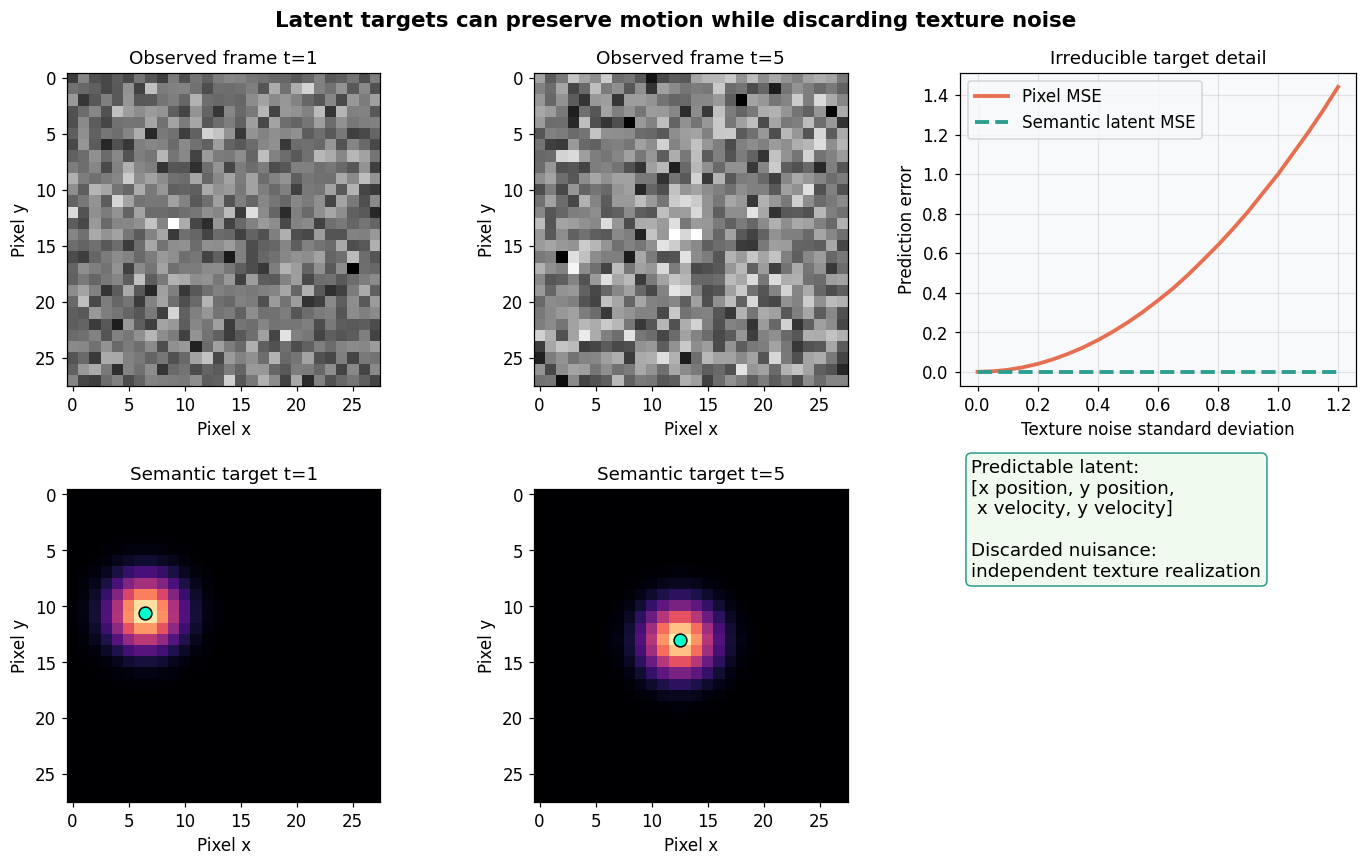

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Latent targets can preserve motion while discarding texture noise', fontsize=14, fontweight='bold')

for column, time_index in enumerate([1, 5]):
    axes[0, column].imshow(textured_video_exp3[time_index], cmap='gray')
    axes[0, column].set_title(f'Observed frame t={time_index}')
    axes[1, column].imshow(semantic_video_exp3[time_index], cmap='magma', vmin=0, vmax=1)
    axes[1, column].scatter(*centers_exp3[time_index], c='#00ffcc', s=70, edgecolors='black')
    axes[1, column].set_title(f'Semantic target t={time_index}')
    for row in range(2):
        axes[row, column].set_xlabel('Pixel x')
        axes[row, column].set_ylabel('Pixel y')

axes[0, 2].plot(texture_levels_exp3, pixel_error_exp3, color='#e76f51', linewidth=2.5, label='Pixel MSE')
axes[0, 2].plot(texture_levels_exp3, latent_error_exp3, '--', color='#2a9d8f', linewidth=2.5, label='Semantic latent MSE')
axes[0, 2].set_xlabel('Texture noise standard deviation')
axes[0, 2].set_ylabel('Prediction error')
axes[0, 2].set_title('Irreducible target detail')
axes[0, 2].grid(alpha=0.3)
axes[0, 2].legend()

axes[1, 2].axis('off')
axes[1, 2].text(
    0.03, 0.72,
    'Predictable latent:\n[x position, y position,\n x velocity, y velocity]\n\nDiscarded nuisance:\nindependent texture realization',
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='#f1faee', edgecolor='#2a9d8f'),
)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Pixel error grows quadratically with texture strength, while the chosen semantic motion target is unchanged.
2. **Why it looks this way:** Independent texture cannot be inferred from context, but object position and velocity follow a stable trajectory.
3. **Key takeaway:** A learned feature target can allocate capacity to predictable motion and appearance rather than every RGB fluctuation.

---
## Experiment 4: Masked completion is not causal forecasting

**Question:** Why should V-JEPA 2024 not be treated as an action-conditioned future model by default?

A masked target in the middle of a clip may use observations from both sides. Causal forecasting can use only the past. The two conditionals contain different information.

In [8]:
time_exp4 = np.arange(16)
true_position_exp4 = 0.18 * time_exp4 ** 2 - 1.2 * time_exp4 + 4.0
observed_position_exp4 = true_position_exp4 + np.array([
    0.15, -0.10, 0.08, -0.04, 0.12, 0.00, -0.06, 0.09,
    -0.05, 0.03, -0.08, 0.11, -0.09, 0.06, -0.03, 0.05,
])

masked_times_exp4 = np.arange(6, 10)
visible_exp4 = ~np.isin(time_exp4, masked_times_exp4)
past_only_exp4 = time_exp4 < masked_times_exp4.min()

bidirectional_coeff_exp4 = np.polyfit(time_exp4[visible_exp4], observed_position_exp4[visible_exp4], deg=2)
causal_coeff_exp4 = np.polyfit(time_exp4[past_only_exp4], observed_position_exp4[past_only_exp4], deg=1)
bidirectional_prediction_exp4 = np.polyval(bidirectional_coeff_exp4, masked_times_exp4)
causal_prediction_exp4 = np.polyval(causal_coeff_exp4, masked_times_exp4)

bidirectional_mse_exp4 = np.mean((bidirectional_prediction_exp4 - true_position_exp4[masked_times_exp4]) ** 2)
causal_mse_exp4 = np.mean((causal_prediction_exp4 - true_position_exp4[masked_times_exp4]) ** 2)

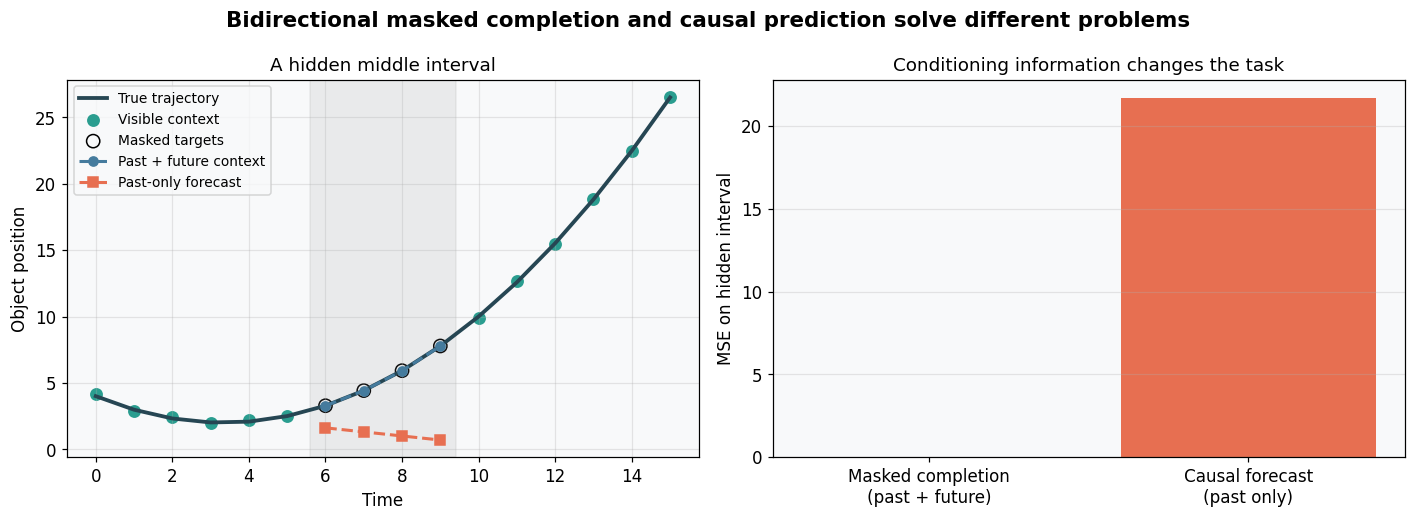

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle('Bidirectional masked completion and causal prediction solve different problems', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(time_exp4, true_position_exp4, color='#264653', linewidth=2.5, label='True trajectory')
ax.scatter(time_exp4[visible_exp4], observed_position_exp4[visible_exp4], color='#2a9d8f', s=55, label='Visible context')
ax.scatter(masked_times_exp4, true_position_exp4[masked_times_exp4], facecolors='none', edgecolors='black', s=75, label='Masked targets')
ax.plot(masked_times_exp4, bidirectional_prediction_exp4, 'o--', color='#457b9d', linewidth=2, label='Past + future context')
ax.plot(masked_times_exp4, causal_prediction_exp4, 's--', color='#e76f51', linewidth=2, label='Past-only forecast')
ax.axvspan(masked_times_exp4.min() - 0.4, masked_times_exp4.max() + 0.4, color='gray', alpha=0.12)
ax.set_xlabel('Time')
ax.set_ylabel('Object position')
ax.set_title('A hidden middle interval')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(
    ['Masked completion\n(past + future)', 'Causal forecast\n(past only)'],
    [bidirectional_mse_exp4, causal_mse_exp4],
    color=['#457b9d', '#e76f51'],
)
ax.set_ylabel('MSE on hidden interval')
ax.set_title('Conditioning information changes the task')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The bidirectional completion model uses points after the hidden interval and reconstructs the curved trajectory more accurately than the past-only linear forecast.
2. **Why it looks this way:** V-JEPA's visible set can contain tokens on both temporal sides of a target tube. A causal model is forbidden from using future evidence.
3. **Key takeaway:** Strong masked-video features do not by themselves provide an action-conditioned transition model or causal rollout operator.

---
## Summary / Key Takeaways

| Experiment | Key insight |
|---|---|
| 1. Temporal leakage | Tube masks prevent direct copying from adjacent frames. |
| 2. Mask families | Small and large block unions train complementary spatial reasoning ranges. |
| 3. Feature targets | Latent prediction can preserve predictable motion while ignoring texture noise. |
| 4. Completion vs forecasting | Bidirectional masked completion is not causal future prediction. |

### Connection to the broader theory

V-JEPA preserves the JEPA encoder-target-predictor contract while replacing a 2D patch grid with a 3D spatiotemporal token grid. Its central video-specific choice is the tube mask: a spatial region remains hidden across the clip so temporal redundancy cannot trivialize the feature-prediction task.